# MLPR LAB 7
PROSHITA AGARWAL

In [48]:
# STEP 1
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

In [49]:
# STEP 2
# loading csv files
odi = pd.read_csv('virat_kohli_odi_innings_data.csv')
t20 = pd.read_csv('virat_kohli_t20i_innings_data.csv')
test = pd.read_csv('virat_kohli_test_innings_data.csv')

In [50]:
# STEP 3
# creating arrays fo runs, strike rates and ground across the 3 csv files
RUNS = np.concatenate((odi['Runs'], t20['Runs'], test['Runs']))
STRIKE = np.concatenate((odi['SR'], t20['SR'], test['SR']))
GROUND = np.concatenate((odi['Ground'], t20['Ground'], test['Ground']))

In [51]:
# STEP 4
# getting match type data
match_type = np.concatenate((np.repeat("ODI", len(odi['Runs'])), 
                            np.repeat("T20", len(t20['Runs'])), 
                            np.repeat("TEST", len(test['Runs']))))

In [52]:
# STEP 5.1
# creating data frame
data_cricketer = pd.DataFrame({'Runs': RUNS, 'Strike': STRIKE, 'Match Type': match_type})

In [53]:
# STEP 5.2
# cleaning data frame
# converting Runs and SR to numeric (in case they are stored as strings)
data_cricketer['Runs'] = pd.to_numeric(data_cricketer['Runs'], errors='coerce')
data_cricketer['Strike'] = pd.to_numeric(data_cricketer['Strike'], errors='coerce')

# removing rows with missing values
data_cricketer = data_cricketer.dropna()

# removing invalid strike rates(since strike rates can never be negative)
data_cricketer = data_cricketer[data_cricketer['Strike'] > 0]

In [54]:
# STEP 6
X = data_cricketer[['Runs', 'Strike']]
Y = data_cricketer['Match Type']

In [55]:
#STEP 7
x_train, x_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.3,
    random_state=0
)

In [56]:
#STEP 8
model = SVC(kernel='poly', degree=6)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [57]:
# STEP 9
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# balanced accuracy
bal_acc = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy:", bal_acc)

Confusion Matrix:
 [[48  4 17]
 [ 8 23  2]
 [ 3  1 44]]
Accuracy: 0.7666666666666667
Balanced Accuracy: 0.7697628458498024


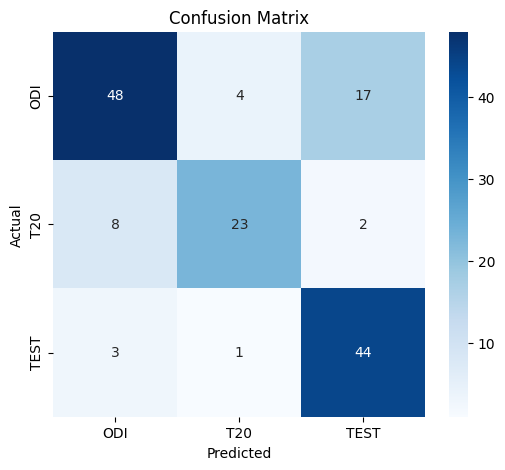

In [58]:
# STEP 10
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [39]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

         ODI       0.81      0.70      0.75        69
         T20       0.82      0.70      0.75        33
        TEST       0.70      0.92      0.79        48

    accuracy                           0.77       150
   macro avg       0.78      0.77      0.77       150
weighted avg       0.78      0.77      0.76       150



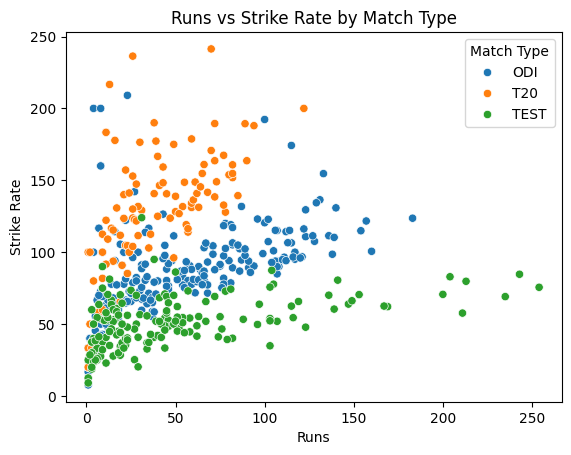

In [41]:
sns.scatterplot(
    data=data_cricketer,
    x='Runs',
    y='Strike',
    hue='Match Type'
)

plt.xlabel("Runs")
plt.ylabel("Strike Rate")
plt.title("Runs vs Strike Rate by Match Type")
plt.legend(title="Match Type")
plt.show()

# REPORT

### 1. What are Support Vectors in SVM? How do they help in making SVM less prone to outliers?

Support vectors are the specific data points that lie closest to the decision boundary (also called the hyperplane). These points are the most important elements in an SVM model because they directly determine the position and orientation of the boundary. Instead of using all data points to create the classifier, SVM focuses only on these critical boundary points. This makes the model more stable and less sensitive to outliers, because points that are far away from the boundary do not influence the model. In the case of soft margin SVM, minor outliers are allowed without drastically shifting the boundary.

### 2. What is the difference between a hard margin and a soft margin in SVM?

A hard margin SVM tries to perfectly separate the data without allowing any misclassification. It works only when the data is completely linearly separable and contains no noise. Even a single outlier can make a hard margin model fail. In contrast, a soft margin SVM allows some misclassifications in order to create a better and more generalized boundary. It introduces a regularization parameter that controls the trade-off between maximizing the margin and minimizing classification errors. Soft margin is more practical because real-world data usually contains noise.

### 3. How does SVM deal with non-linear classification boundaries?

SVM handles non-linear classification problems using something called the kernel trick. Instead of trying to draw a straight line in the original feature space, the kernel function maps the data into a higher-dimensional space where it becomes linearly separable. For example, the polynomial kernel (used in this lab) creates curved decision boundaries by transforming the features into higher-degree combinations. This allows SVM to separate complex patterns that cannot be divided using a simple straight line.

### 4. What is the role of gamma in SVM? How does the value of gamma impact underfitting and overfitting?

Gamma is a parameter used in certain SVM kernels, especially the RBF kernel. It controls how far the influence of a single training example reaches. A low gamma value means that the influence spreads far, resulting in a smoother and simpler decision boundary, which may cause underfitting. A high gamma value means the influence is very limited, leading to a highly complex boundary that closely fits the training data, which may cause overfitting. Therefore, choosing the right gamma value is important to balance bias and variance.

### 5. How are SVMs used for multi-class classification problems?

SVM is naturally a binary classifier, meaning it separates data into two classes. For multi-class problems, strategies like One-vs-Rest (OvR) or One-vs-One (OvO) are used. In the One-vs-Rest approach, a separate classifier is trained for each class against all other classes. In the One-vs-One approach, classifiers are trained for every possible pair of classes. The final prediction is made based on voting or decision scores. In this lab, since we classified ODI, T20, and TEST matches, the SVM internally used such a strategy to handle the three classes.